In [76]:
import pandas as pd 
import numpy as np 
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import tensorflow as tf
import matplotlib.pyplot as plt


In [77]:
#zmienna do przewidywania cena aktualna 

df = pd.read_csv('../backend/data/dane_do_modelu.csv')

In [78]:
q99 = df['cena_aktualna'].quantile(0.99)

df = df[df['cena_aktualna'] < q99]

In [79]:
target = 'cena_aktualna'
X = df.drop(columns= target)
y = np.log1p(df[target])
#y = df[target]


In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= 0.2 )

In [81]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_28540\3112228624.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


In [82]:
cat_proces = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [83]:
num_proces = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

In [84]:
preproccesing = ColumnTransformer([
    ('num_processing', num_proces, num_cols),
    ('cat_processing', cat_proces, cat_cols)
])

In [24]:
models = {
    #'catboost' : CatBoostRegressor(),
    'XGBRegressor' : XGBRegressor(),
    'Random_forest': RandomForestRegressor(),
    'lightbm': LGBMRegressor()
}

In [85]:
X_train_prep = preproccesing.fit_transform(X_train)
X_test_prep = preproccesing.transform(X_test)


In [ ]:
# MODEL KONCOWY 
model_dl = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_prep.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

model_dl.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model_dl.fit(
    X_train_prep, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_prep, y_test)
)

loss, mae = model_dl.evaluate(X_test_prep, y_test)
print(loss, mae)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.5560 - mae: 1.0369 - val_loss: 0.4045 - val_mae: 0.5094
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4033 - mae: 0.5044 - val_loss: 0.4123 - val_mae: 0.5171
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3766 - mae: 0.4871 - val_loss: 0.3319 - val_mae: 0.4698
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3462 - mae: 0.4661 - val_loss: 0.3043 - val_mae: 0.4576
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2898 - mae: 0.4238 - val_loss: 0.3104 - val_mae: 0.4648
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2468 - mae: 0.3896 - val_loss: 0.2326 - val_mae: 0.3812
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2376 - mae: 0.3811 - val_loss: 0.2364 - val_mae: 0.3765
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2198 - mae: 0.3644 - val_loss: 0.2191 - val_mae: 0.3759
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2338 - mae: 

In [111]:
y_pred_log = model_dl.predict(X_test_prep).ravel()

y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae_real = mean_absolute_error(y_test_real, y_pred)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred))

print(mae_real)

print(rmse_real)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
62.58049130634509
89.42750095195225


In [116]:
def price_bucket(p):
    if p < 100:
        return "tani"
    elif p < 250:
        return "średni"
    else:
        return "premium"

In [117]:
y_pred_class = pd.Series(y_pred).apply(price_bucket)
y_true_class = pd.Series(y_test_real).apply(price_bucket)

In [118]:
from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(y_true_class, y_pred_class)

print("Accuracy segmentów:", acc)
print(classification_report(y_true_class, y_pred_class))

Accuracy segmentów: 0.6926315789473684
              precision    recall  f1-score   support

     premium       0.66      0.73      0.69       114
        tani       0.94      0.47      0.63       137
      średni       0.64      0.81      0.72       224

    accuracy                           0.69       475
   macro avg       0.75      0.67      0.68       475
weighted avg       0.73      0.69      0.69       475



In [119]:
df.columns

Index(['nazwa', 'marka', 'cena_aktualna', 'dlugosc_rekawa', 'fason_clean',
       'trend_score', 'bawełna_pct', 'poliester_pct', 'elastan_pct',
       'wiskoza_pct', 'wełna_pct', 'len_pct', 'jedwab_pct', 'nylon_pct',
       'poliamid_pct', 'lyocell_pct', 'modal_pct', 'akryl_pct', 'kaszmir_pct',
       'poliuretan_pct', 'natural_material_pct', 'synthetic_material_pct',
       'premium_material_pct'],
      dtype='str')

In [123]:
df['dlugosc_rekawa'].value_counts()

dlugosc_rekawa
Krótki rękaw                1950
Półrękawek                   193
Długi rękaw                  147
Bez rękawów                   58
Bardzo długi rękaw            16
Bardzo krótki rękawek          8
Krótki rękaw, półrękawek       1
Name: count, dtype: int64

In [31]:

results = []
pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('procesowanie', preproccesing),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    y_pred = np.expm1(y_pred)
    y_test_real = np.expm1(y_test)

    mae = mean_absolute_error(y_test_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))

    #mae = mean_absolute_error(y_test, y_pred)
    #rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append((name, mae, rmse))
    pipelines[name] = pipeline 

    results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE'])
    print(results_df.sort_values('MAE'))

          Model        MAE       RMSE
0  XGBRegressor  53.372282  81.286631
           Model        MAE       RMSE
0   XGBRegressor  53.372282  81.286631
1  Random_forest  53.540341  84.266173
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 215
[LightGBM] [Info] Number of data points in the train set: 1898, number of used features: 44
[LightGBM] [Info] Start training from score 5.007036
           Model        MAE        RMSE
0   XGBRegressor  53.372282   81.286631
1  Random_forest  53.540341   84.266173
2        lightbm  68.710634  105.880675


c:\Users\Thinkpad\miniconda3\envs\ml-env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [32]:
best_model_name = results_df.sort_values('MAE').iloc[0]['Model']
best_pipeline = pipelines[best_model_name]

In [33]:
importances = best_pipeline.named_steps['model'].feature_importances_
features = best_pipeline.named_steps['procesowanie'].get_feature_names_out()

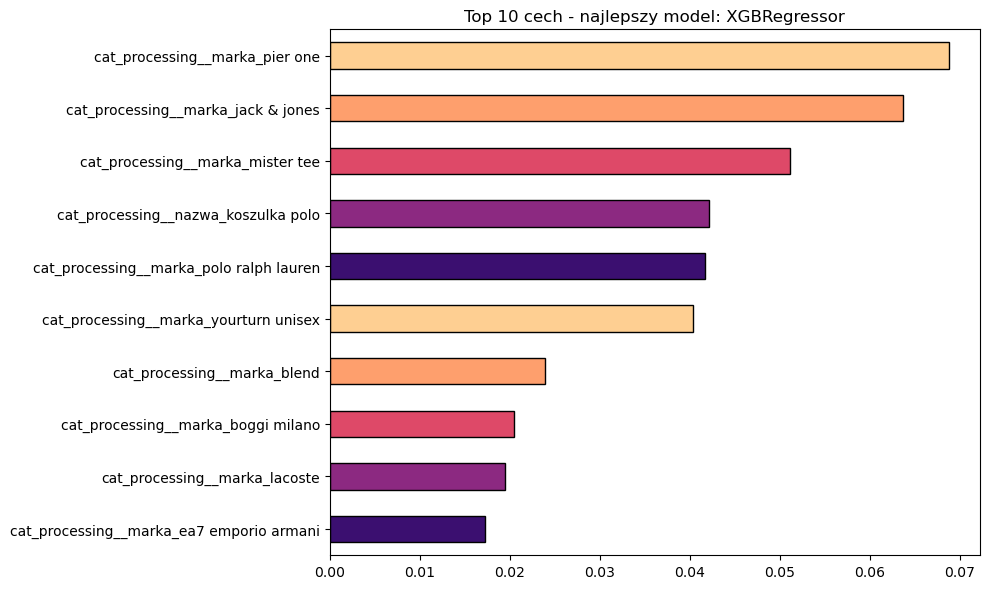

In [39]:
plt.figure(figsize=(10, 6))

pd.Series(importances, index=features)\
    .sort_values()\
    .tail(10)\
    .plot(
        kind='barh',
        color=plt.cm.magma([0.2, 0.4, 0.6, 0.8, 0.9]),
        edgecolor='black'
    )

plt.title(f"Top 10 cech - najlepszy model: {best_model_name}")
plt.tight_layout()
plt.show()